# 卷积神经网络

在上一单元中，我们学习了如何使用类定义来构建一个多层神经网络，但这些网络是通用的，并未针对计算机视觉任务进行优化。在本单元中，我们将学习**卷积神经网络（CNNs）**，它们是专门为计算机视觉设计的。

计算机视觉与通用分类不同，因为当我们试图在图片中找到某个特定对象时，我们实际上是在扫描图像，寻找一些特定的**模式**及其组合。例如，当寻找一只猫时，我们可能会先寻找水平线条，这些线条可能形成胡须，然后某些胡须的组合可以告诉我们这确实是一只猫的图片。某些模式的相对位置和存在性是重要的，而它们在图像中的确切位置并不重要。

为了提取这些模式，我们将使用**卷积滤波器**的概念。但首先，让我们加载所有在之前单元中定义的依赖项和函数。


In [7]:
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from torchinfo import summary
import numpy as np

from pytorchcv import load_mnist, train, plot_results, plot_convolution, display_dataset
load_mnist(batch_size=128)

## 卷积滤波器

卷积滤波器是小型窗口，它会遍历图像的每个像素，并计算邻近像素的加权平均值。



它们由权重系数矩阵定义。让我们来看两个不同的卷积滤波器在我们的 MNIST 手写数字上的应用示例：


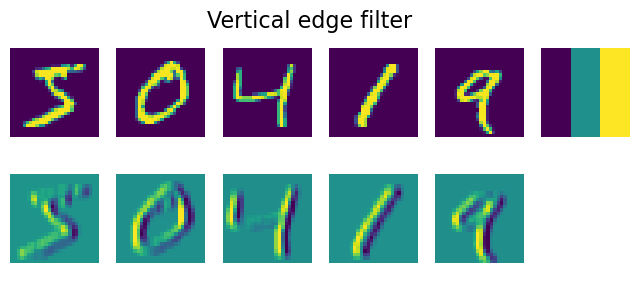

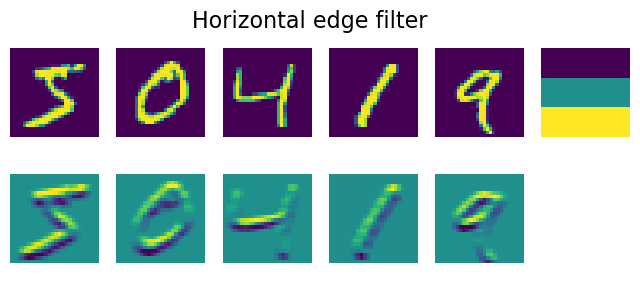

In [2]:
plot_convolution(torch.tensor([[-1.,0.,1.],[-1.,0.,1.],[-1.,0.,1.]]),'Vertical edge filter')
plot_convolution(torch.tensor([[-1.,-1.,-1.],[0.,0.,0.],[1.,1.,1.]]),'Horizontal edge filter')


第一个滤波器称为**垂直边缘滤波器**，其定义如下矩阵：
$$
\left(
    \begin{matrix}
     -1 & 0 & 1 \cr
     -1 & 0 & 1 \cr
     -1 & 0 & 1 \cr
    \end{matrix}
\right)
$$
当这个滤波器作用于相对均匀的像素区域时，所有值相加的结果为0。然而，当它遇到图像中的垂直边缘时，会产生一个较高的峰值。这就是为什么在上面的图像中，你可以看到垂直边缘以高值和低值的形式表现出来，而水平边缘则被平均化了。

当我们应用水平边缘滤波器时，情况正好相反——水平线被放大，而垂直线被平均化。

在传统的计算机视觉中，会对图像应用多个滤波器以生成特征，然后通过机器学习算法利用这些特征来构建分类器。然而，在深度学习中，我们构建的网络会**学习**最佳的卷积滤波器来解决分类问题。

为此，我们引入了**卷积层**。


## 卷积层

卷积层通过 `nn.Conv2d` 构造定义。我们需要指定以下参数：
* `in_channels` - 输入通道数。在我们的例子中，我们处理的是灰度图像，因此输入通道数为 1。
* `out_channels` - 使用的滤波器数量。我们将使用 9 个不同的滤波器，这将为网络提供充足的机会来探索哪些滤波器最适合我们的场景。
* `kernel_size` 是滑动窗口的大小。通常使用 3x3 或 5x5 的滤波器。

最简单的 CNN 将包含一个卷积层。给定输入大小为 28x28，在应用九个 5x5 滤波器后，我们将得到一个大小为 9x24x24 的张量（空间大小变小了，因为在 28 像素中，长度为 5 的滑动区间只有 24 个位置可以适配）。

在卷积之后，我们将 9x24x24 的张量展平为一个大小为 5184 的向量，然后添加线性层以生成 10 个类别。在层之间，我们还使用了 `relu` 激活函数。


In [11]:
class OneConv(nn.Module):
    def __init__(self):
        super(OneConv, self).__init__()
        self.conv = nn.Conv2d(in_channels=1,out_channels=9,kernel_size=(5,5))
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(5184,10)

    def forward(self, x):
        x = nn.functional.relu(self.conv(x))
        x = self.flatten(x)
        x = nn.functional.log_softmax(self.fc(x),dim=1)
        return x

net = OneConv()

summary(net,input_size=(1,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
OneConv                                  [1, 10]                   --
├─Conv2d: 1-1                            [1, 9, 24, 24]            234
├─Flatten: 1-2                           [1, 5184]                 --
├─Linear: 1-3                            [1, 10]                   51,850
Total params: 52,084
Trainable params: 52,084
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.19
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.21
Estimated Total Size (MB): 0.25

你可以看到这个网络包含大约50k个可训练参数，而全连接多层网络则大约有80k个。这使我们即使在较小的数据集上也能取得良好的结果，因为卷积网络的泛化能力要好得多。


Epoch  0, Train acc=0.950, Val acc=0.974, Train loss=0.001, Val loss=0.001
Epoch  1, Train acc=0.980, Val acc=0.981, Train loss=0.001, Val loss=0.000
Epoch  2, Train acc=0.986, Val acc=0.977, Train loss=0.000, Val loss=0.001
Epoch  3, Train acc=0.989, Val acc=0.976, Train loss=0.000, Val loss=0.001
Epoch  4, Train acc=0.991, Val acc=0.978, Train loss=0.000, Val loss=0.001


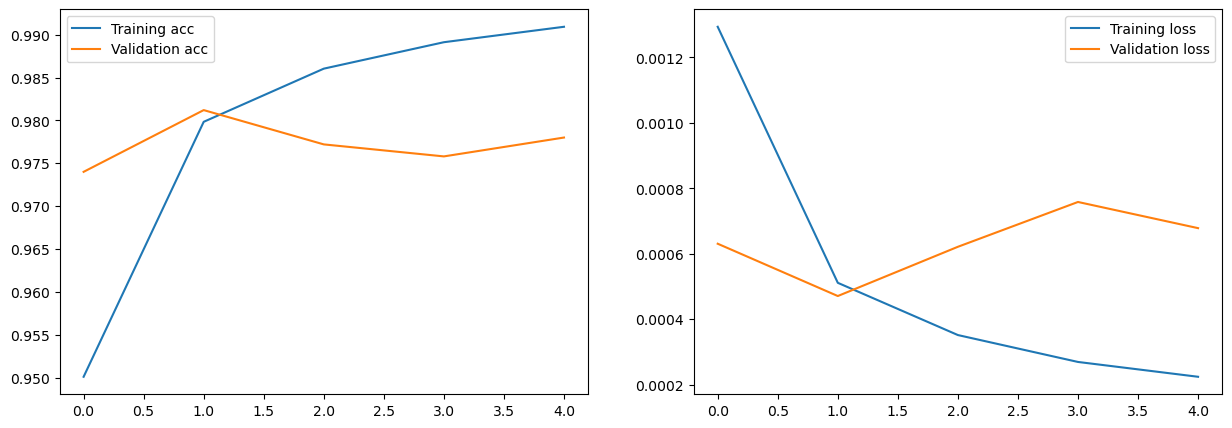

In [12]:
hist = train(net,train_loader,test_loader,epochs=5)
plot_results(hist)

正如你所看到的，与上一单元中的全连接网络相比，我们能够实现更高的准确性，并且速度更快。

我们还可以可视化训练好的卷积层的权重，以更好地理解其工作原理：


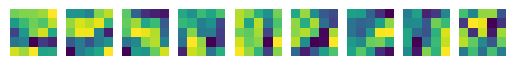

In [5]:
fig,ax = plt.subplots(1,9)
with torch.no_grad():
    p = next(net.conv.parameters())#卷积核参数(out_channels, in_channels, kernel_height, kernel_width)
    for i,x in enumerate(p):#x为inchannels...
        ax[i].imshow(x.detach().cpu()[0,...])
        ax[i].axis('off')

你可以看到，有些滤波器似乎能够识别一些斜线，而其他的看起来则相当随机。

## 多层 CNN 和池化层

第一层卷积层会寻找一些基础的模式，比如水平线或垂直线，但我们可以在这些基础模式之上应用更多的卷积层，以寻找更高级的模式，比如基础形状。接着，更多的卷积层可以将这些形状组合成图片中的某些部分，最终到达我们试图分类的目标对象。

在此过程中，我们还可以应用一个技巧：缩小图像的空间尺寸。一旦我们检测到在滑动的 3x3 窗口内存在一条水平线，具体发生在哪个像素点就不那么重要了。因此，我们可以通过使用一种 **池化层** 来“缩小”图像的尺寸：

 * **平均池化** 使用一个滑动窗口（例如，2x2 像素）并计算窗口内值的平均值。
 * **最大池化** 用窗口内的最大值替换窗口。最大池化的背后理念是检测滑动窗口内是否存在某种模式。

因此，在一个典型的 CNN 中，会有若干卷积层，并在它们之间插入池化层以减少图像的维度。同时，我们还会增加滤波器的数量，因为随着模式变得更加复杂，我们需要寻找的可能的有趣组合也会更多。

![一张展示多个卷积层和池化层的图片。](../../../../../lessons/4-ComputerVision/07-ConvNets/images/cnn-pyramid.png)

由于空间维度的减少和特征/滤波器维度的增加，这种架构也被称为 **金字塔架构**。


In [4]:
class MultiLayerCNN(nn.Module):
    def __init__(self):
        super(MultiLayerCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(10, 20, 5)
        self.fc = nn.Linear(320,10)

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.conv1(x)))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = x.view(-1, 320)
        x = nn.functional.log_softmax(self.fc(x),dim=1)
        return x

net = MultiLayerCNN()
summary(net,input_size=(1,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
MultiLayerCNN                            [1, 10]                   --
├─Conv2d: 1-1                            [1, 10, 24, 24]           260
├─MaxPool2d: 1-2                         [1, 10, 12, 12]           --
├─Conv2d: 1-3                            [1, 20, 8, 8]             5,020
├─MaxPool2d: 1-4                         [1, 20, 4, 4]             --
├─Linear: 1-5                            [1, 10]                   3,210
Total params: 8,490
Trainable params: 8,490
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.47
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.03
Estimated Total Size (MB): 0.09

注意以下几点：
* 我们没有使用 `Flatten` 层，而是在 `forward` 函数中通过 `view` 函数对张量进行展平。由于展平层没有可训练的权重，因此在我们的类中创建一个单独的层实例并不是必要的。
* 我们的模型中只使用了一个池化层实例，这也是因为它不包含任何可训练参数，这个实例可以被有效地重复使用。
* 可训练参数的数量（约8.5K）比之前的情况显著减少。这是因为卷积层通常具有较少的参数，并且在应用最终的全连接层之前，图像的维度已经显著降低。参数数量较少对我们的模型有积极影响，因为它有助于防止在较小的数据集上出现过拟合问题。


In [13]:
hist = train(net,train_loader,test_loader,epochs=5)

Epoch  0, Train acc=0.992, Val acc=0.979, Train loss=0.000, Val loss=0.001
Epoch  1, Train acc=0.992, Val acc=0.976, Train loss=0.000, Val loss=0.001
Epoch  2, Train acc=0.994, Val acc=0.977, Train loss=0.000, Val loss=0.001
Epoch  3, Train acc=0.994, Val acc=0.978, Train loss=0.000, Val loss=0.001
Epoch  4, Train acc=0.995, Val acc=0.980, Train loss=0.000, Val loss=0.001


我们可以注意到，与仅使用一层相比，我们能够实现更高的准确率，而且速度更快——只需1到2个epoch。这意味着复杂的网络架构需要更少的数据就能理解问题的本质，并从我们的图像中提取通用模式。

## 使用CIFAR-10数据集中的真实图像进行实验

虽然手写数字识别问题看起来像是一个简单的练习，但我们现在已经准备好处理更复杂的问题了。让我们探索一个更高级的数据集——包含不同物体图片的[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html)。该数据集包含6万张32x32的图像，分为10个类别。


In [17]:
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=14, shuffle=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=14, shuffle=False)
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


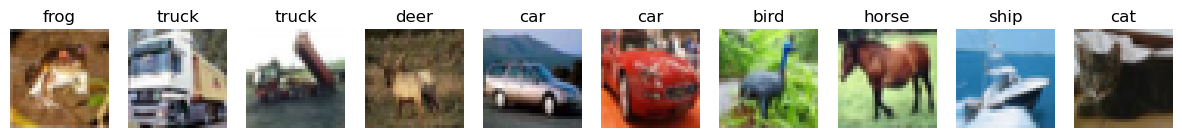

In [18]:
display_dataset(trainset,classes=classes)

一个著名的 CIFAR-10 架构叫做 [LeNet](https://en.wikipedia.org/wiki/LeNet)，由 *Yann LeCun* 提出。它遵循了我们上面提到的相同原则，主要的区别在于输入是 3 个颜色通道，而不是 1 个。

我们对这个模型还做了一个简化——我们不使用 `log_softmax` 作为输出激活函数，而是直接返回最后一个全连接层的输出。在这种情况下，我们可以直接使用 `CrossEntropyLoss` 损失函数来优化模型。


In [19]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.conv3 = nn.Conv2d(16,120,5)
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(120,64)
        self.fc2 = nn.Linear(64,10)

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.conv1(x)))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = nn.functional.relu(self.conv3(x))
        x = self.flat(x)
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net = LeNet()

summary(net,input_size=(1,3,32,32))

Layer (type:depth-idx)                   Output Shape              Param #
LeNet                                    [1, 10]                   --
├─Conv2d: 1-1                            [1, 6, 28, 28]            456
├─MaxPool2d: 1-2                         [1, 6, 14, 14]            --
├─Conv2d: 1-3                            [1, 16, 10, 10]           2,416
├─MaxPool2d: 1-4                         [1, 16, 5, 5]             --
├─Conv2d: 1-5                            [1, 120, 1, 1]            48,120
├─Flatten: 1-6                           [1, 120]                  --
├─Linear: 1-7                            [1, 64]                   7,744
├─Linear: 1-8                            [1, 10]                   650
Total params: 59,386
Trainable params: 59,386
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.66
Input size (MB): 0.01
Forward/backward pass size (MB): 0.05
Params size (MB): 0.24
Estimated Total Size (MB): 0.30

正确训练这个网络将需要大量时间，最好在支持GPU的计算设备上进行。


In [20]:
opt = torch.optim.SGD(net.parameters(),lr=0.001,momentum=0.9)
hist = train(net, trainloader, testloader, epochs=3, optimizer=opt, loss_fn=nn.CrossEntropyLoss())

Epoch  0, Train acc=0.252, Val acc=0.387, Train loss=0.145, Val loss=0.120
Epoch  1, Train acc=0.434, Val acc=0.466, Train loss=0.111, Val loss=0.106
Epoch  2, Train acc=0.504, Val acc=0.530, Train loss=0.099, Val loss=0.094


我们通过训练3个周期所达到的准确率似乎并不理想。然而，请记住，盲目猜测的准确率只有10%，而我们的问题实际上比MNIST数字分类要复杂得多。在如此短的训练时间内达到超过50%的准确率已经是一个不错的成就。

## 关键点

在本单元中，我们学习了计算机视觉神经网络的核心概念——卷积网络。现实生活中用于图像分类、目标检测甚至图像生成的网络架构都基于CNN，只是增加了更多的层以及一些额外的训练技巧。



---

**免责声明**：  
本文档使用AI翻译服务 [Co-op Translator](https://github.com/Azure/co-op-translator) 进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。应以原始语言的文档作为权威来源。对于关键信息，建议使用专业人工翻译。我们不对因使用此翻译而产生的任何误解或误读承担责任。
